In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import numpy as np
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=32, shuffle=False, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:11<00:00, 15.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [2]:
print(f"trainset_size: {len(trainset)}")
print(f"valset_size: {len(valset)}")
print(f"testset_size: {len(testset)}")
print(f"all_size: {len(trainset) + len(valset) + len(testset)}")
print(f"classes_num: {len(classes)}")
train_class_counts = [0] * len(classes)
for _, label in trainset:
    train_class_counts[label] += 1
print("\nDistribution of training set categories:")
for i, count in enumerate(train_class_counts):
    print(f"{classes[i]}: {count}")

val_class_counts = [0] * len(classes)
for _, label in valset:
    val_class_counts[label] += 1
print("\nDistribution of validation set categories:")
for i, count in enumerate(val_class_counts):
    print(f"{classes[i]}: {count}")

test_class_counts = [0] * len(classes)
for _, label in testset:
    test_class_counts[label] += 1
print("\nDistribution of testing set categories:")
for i, count in enumerate(test_class_counts):
    print(f"{classes[i]}: {count}")

trainset_size: 40000
valset_size: 10000
testset_size: 10000
all_size: 60000
classes_num: 10

Distribution of training set categories:
plane: 3959
car: 3984
bird: 4047
cat: 3991
deer: 3965
dog: 4041
frog: 3974
horse: 4026
ship: 4000
truck: 4013

Distribution of validation set categories:
plane: 1041
car: 1016
bird: 953
cat: 1009
deer: 1035
dog: 959
frog: 1026
horse: 974
ship: 1000
truck: 987

Distribution of testing set categories:
plane: 1000
car: 1000
bird: 1000
cat: 1000
deer: 1000
dog: 1000
frog: 1000
horse: 1000
ship: 1000
truck: 1000


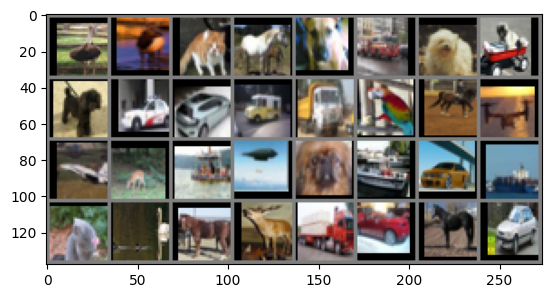

bird  deer  cat   horse dog   truck dog   dog   
dog   car   car   truck truck bird  horse plane 
plane deer  ship  plane dog   ship  car   ship  
cat   bird  horse deer  truck car   horse car   


In [3]:
import matplotlib.pyplot as plt
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images))
for i, label_idx in enumerate(labels):
    print(f"{classes[label_idx]:5s}", end=' ')
    if (i + 1) % 8 == 0:
        print()

In [4]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.Dropout(0.25),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Dropout(0.25),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Dropout(0.25),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.Dropout(0.25),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Dropout(0.25),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Dropout(0.25),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [5]:
model = VGG()
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

Parameter Name      | Shape                        | Requires Grad
-------------------------------------------------------------------
features.0.weight   | torch.Size([64, 3, 3, 3])    | True
features.0.bias     | torch.Size([64])             | True
features.2.weight   | torch.Size([64])             | True
features.2.bias     | torch.Size([64])             | True
features.4.weight   | torch.Size([64, 64, 3, 3])   | True
features.4.bias     | torch.Size([64])             | True
features.6.weight   | torch.Size([64])             | True
features.6.bias     | torch.Size([64])             | True
features.8.weight   | torch.Size([128, 64, 3, 3])  | True
features.8.bias     | torch.Size([128])            | True
features.10.weight  | torch.Size([128])            | True
features.10.bias    | torch.Size([128])            | True
features.12.weight  | torch.Size([128, 128, 3, 3]) | True
features.12.bias    | torch.Size([128])            | True
features.14.weight  | torch.Size([128])            | 

In [6]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

In [7]:
model = ResNet18()
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

Parameter Name             | Shape                        | Requires Grad
--------------------------------------------------------------------------
conv1.weight               | torch.Size([64, 3, 3, 3])    | True
bn1.weight                 | torch.Size([64])             | True
bn1.bias                   | torch.Size([64])             | True
layer1.0.conv1.weight      | torch.Size([64, 64, 3, 3])   | True
layer1.0.bn1.weight        | torch.Size([64])             | True
layer1.0.bn1.bias          | torch.Size([64])             | True
layer1.0.conv2.weight      | torch.Size([64, 64, 3, 3])   | True
layer1.0.bn2.weight        | torch.Size([64])             | True
layer1.0.bn2.bias          | torch.Size([64])             | True
layer1.1.conv1.weight      | torch.Size([64, 64, 3, 3])   | True
layer1.1.bn1.weight        | torch.Size([64])             | True
layer1.1.bn1.bias          | torch.Size([64])             | True
layer1.1.conv2.weight      | torch.Size([64, 64, 3, 3])   | True
layer1

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert (
                self.head_dim * num_heads == embed_dim
        ), "Embedding dimension needs to be divisible by number of heads"

        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, seq_length, embed_dim = x.size()
        qkv = self.qkv_proj(x)
        qkv = qkv.reshape(batch_size, seq_length, self.num_heads, 3 * self.head_dim).permute(0, 2, 1, 3)
        q, k, v = qkv.chunk(3, dim=-1)
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        values = torch.matmul(attn_probs, v)
        values = values.permute(0, 2, 1, 3).reshape(batch_size, seq_length, embed_dim)
        out = self.out_proj(values)
        return out


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, in_channels=3, num_classes=10,
                 embed_dim=192, num_heads=3, num_layers=12, mlp_dim=768, dropout=0.1):
        super(ViT, self).__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.dropout = nn.Dropout(dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.norm(x)
        cls_token_output = x[:, 0]
        out = self.head(cls_token_output)
        return out

In [9]:
model = ViT()
max_name_len = max(len(name) for name, _ in model.named_parameters())
max_shape_len = max(len(str(param.shape)) for _, param in model.named_parameters())
print(f"{'Parameter Name'.ljust(max_name_len)} | {'Shape'.ljust(max_shape_len)} | Requires Grad")
print("-" * (max_name_len + max_shape_len + 20))
for name, param in model.named_parameters():
    print(
        f"{name.ljust(max_name_len)} | "
        f"{str(param.shape).ljust(max_shape_len)} | "
        f"{param.requires_grad}"
    )

Parameter Name                             | Shape                      | Requires Grad
----------------------------------------------------------------------------------------
cls_token                                  | torch.Size([1, 1, 192])    | True
pos_embed                                  | torch.Size([1, 65, 192])   | True
patch_embed.proj.weight                    | torch.Size([192, 3, 4, 4]) | True
patch_embed.proj.bias                      | torch.Size([192])          | True
transformer_blocks.0.norm1.weight          | torch.Size([192])          | True
transformer_blocks.0.norm1.bias            | torch.Size([192])          | True
transformer_blocks.0.attn.qkv_proj.weight  | torch.Size([576, 192])     | True
transformer_blocks.0.attn.qkv_proj.bias    | torch.Size([576])          | True
transformer_blocks.0.attn.out_proj.weight  | torch.Size([192, 192])     | True
transformer_blocks.0.attn.out_proj.bias    | torch.Size([192])          | True
transformer_blocks.0.norm2.weight

In [10]:
import time
import copy

def train_model(model, model_name, trainloader, valloader, testloader, criterion, optimizer, epochs=5, patience=5):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    start_time = time.time()
    best_accuracy = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    no_improvement_count = 0
    train_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_times = []
    
    for epoch in range(epochs):
        epoch_start_time = time.time()
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(trainloader)
        train_accuracy = 100 * train_correct / train_total
        val_accuracy = evaluate_model(model, valloader)[0]
        epoch_time = time.time() - epoch_start_time
        epoch_times.append(epoch_time)
        
        print(f'Epoch {epoch + 1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, '
              f'Train Acc: {train_accuracy:.2f}%, '
              f'Val Acc: {val_accuracy:.2f}%, '
              f'Time: {epoch_time:.2f}s')
        
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f'{model_name}_best_model.pth')
            no_improvement_count = 0
        else:
            no_improvement_count += 1
        
        if no_improvement_count >= patience:
            print(f'Early stopping at epoch {epoch + 1} due to no improvement in val accuracy.')
            break
    
    total_time = time.time() - start_time
    model.load_state_dict(best_model_wts)
    test_accuracy, inference_time = evaluate_model(model, testloader)
    print(f'\nTraining completed. Best val accuracy: {best_accuracy:.2f}%, '
          f'Test accuracy: {test_accuracy:.2f}%, '
          f'Total training time: {total_time:.2f}s')
    return {
        'model': model,
        'training_time': total_time,
        'best_accuracy': best_accuracy,
        'test_accuracy': test_accuracy,
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'epoch_times': epoch_times
    }

def evaluate_model(model, dataloader):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    start_time = time.time()
    
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    inference_time = time.time() - start_time
    accuracy = 100 * correct / total
    return accuracy, inference_time

In [11]:
def evaluate_model_final(model, dataloader, num_classes=10):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    start_time = time.time()
    with torch.no_grad():
        for data in dataloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += (predicted[i] == label).item()
                class_total[label] += 1
    
    inference_time = time.time() - start_time
    overall_accuracy = 100 * correct / total
    class_accuracies = {}
    for i in range(num_classes):
        if class_total[i] > 0:
            class_accuracies[i] = 100 * class_correct[i] / class_total[i]
        else:
            class_accuracies[i] = 0.0
    
    return {
        'overall_accuracy': overall_accuracy,
        'inference_time': inference_time,
        'class_accuracies': class_accuracies,
        'class_correct': class_correct,
        'class_total': class_total
    }

In [12]:
total_times = {}
train_losses = {}
train_accuracies = {}
test_accuracies = {}
val_accuracies = {}
results = {}

Training VGG...
Epoch 1/150, Train Loss: 1.7589, Train Acc: 34.01%, Val Acc: 41.71%, Time: 38.07s
Epoch 2/150, Train Loss: 1.3359, Train Acc: 51.70%, Val Acc: 49.24%, Time: 38.89s
Epoch 3/150, Train Loss: 1.1151, Train Acc: 60.56%, Val Acc: 58.41%, Time: 39.11s
Epoch 4/150, Train Loss: 0.9689, Train Acc: 66.05%, Val Acc: 64.01%, Time: 38.06s
Epoch 5/150, Train Loss: 0.8563, Train Acc: 70.45%, Val Acc: 67.41%, Time: 38.38s
Epoch 6/150, Train Loss: 0.7695, Train Acc: 73.72%, Val Acc: 70.02%, Time: 38.54s
Epoch 7/150, Train Loss: 0.7082, Train Acc: 75.70%, Val Acc: 70.42%, Time: 38.64s
Epoch 8/150, Train Loss: 0.6507, Train Acc: 77.89%, Val Acc: 74.48%, Time: 38.39s
Epoch 9/150, Train Loss: 0.6181, Train Acc: 78.94%, Val Acc: 73.70%, Time: 38.30s
Epoch 10/150, Train Loss: 0.5761, Train Acc: 80.48%, Val Acc: 76.39%, Time: 38.26s
Epoch 11/150, Train Loss: 0.5473, Train Acc: 81.41%, Val Acc: 78.10%, Time: 38.14s
Epoch 12/150, Train Loss: 0.5184, Train Acc: 82.35%, Val Acc: 77.35%, Time: 38.2

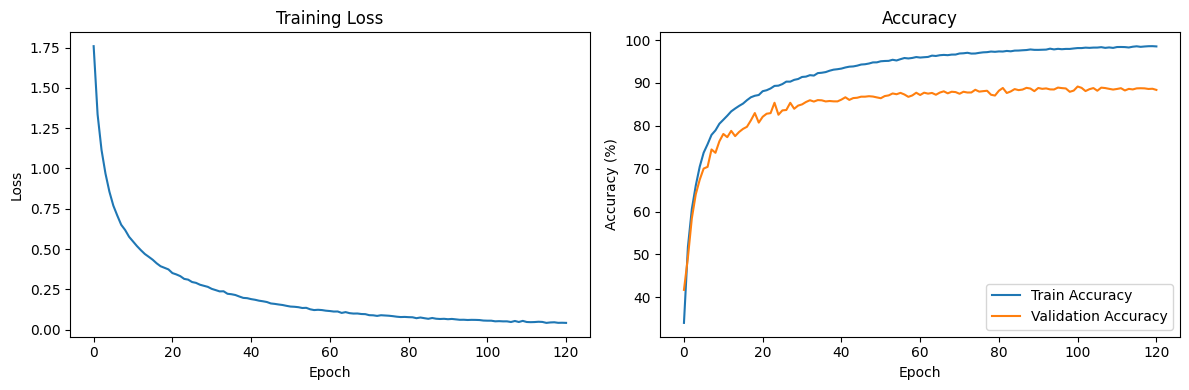

In [13]:
model_name = "VGG"
model = VGG() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=150, patience=20
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


Per-class Accuracy:
plane: 85.00% (850/1000)
car: 93.50% (935/1000)
bird: 84.10% (841/1000)
cat: 78.50% (785/1000)
deer: 88.90% (889/1000)
dog: 82.20% (822/1000)
frog: 94.20% (942/1000)
horse: 89.40% (894/1000)
ship: 96.20% (962/1000)
truck: 91.90% (919/1000)

Final Results for VGG:
Best Validation Accuracy: 89.17%
Test Accuracy: 88.36%
Total Training Time: 4640.90s
Inference Time: 3.3107s per batch


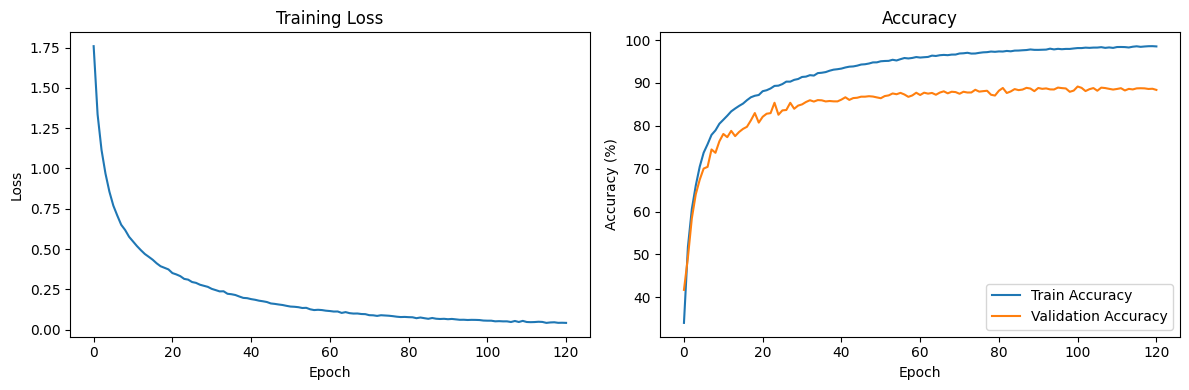

In [14]:
model_name = "VGG"
state_dict = torch.load('/kaggle/working/VGG_best_model.pth', weights_only=True)
model.load_state_dict(state_dict)
training_result['model']=model
accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ResNet...
Epoch 1/150, Train Loss: 1.5019, Train Acc: 44.88%, Val Acc: 53.79%, Time: 46.85s
Epoch 2/150, Train Loss: 1.0656, Train Acc: 61.99%, Val Acc: 65.97%, Time: 46.58s
Epoch 3/150, Train Loss: 0.8546, Train Acc: 70.00%, Val Acc: 72.54%, Time: 46.59s
Epoch 4/150, Train Loss: 0.7202, Train Acc: 74.75%, Val Acc: 75.39%, Time: 46.60s
Epoch 5/150, Train Loss: 0.6277, Train Acc: 78.20%, Val Acc: 77.11%, Time: 46.55s
Epoch 6/150, Train Loss: 0.5609, Train Acc: 80.76%, Val Acc: 79.68%, Time: 46.56s
Epoch 7/150, Train Loss: 0.5131, Train Acc: 82.41%, Val Acc: 80.71%, Time: 46.67s
Epoch 8/150, Train Loss: 0.4746, Train Acc: 83.56%, Val Acc: 82.64%, Time: 46.54s
Epoch 9/150, Train Loss: 0.4320, Train Acc: 85.08%, Val Acc: 84.05%, Time: 46.53s
Epoch 10/150, Train Loss: 0.4042, Train Acc: 86.01%, Val Acc: 83.63%, Time: 46.58s
Epoch 11/150, Train Loss: 0.3794, Train Acc: 87.00%, Val Acc: 84.79%, Time: 46.55s
Epoch 12/150, Train Loss: 0.3472, Train Acc: 88.01%, Val Acc: 84.19%, Time: 4

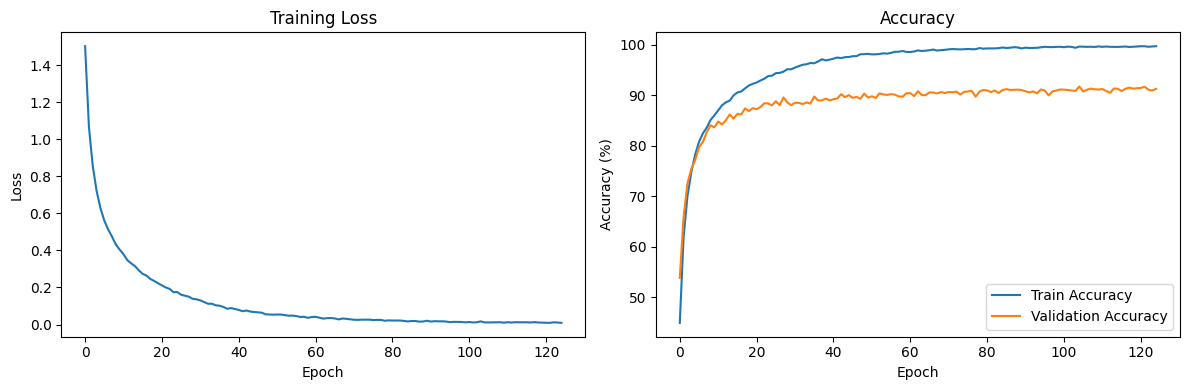

In [15]:
model_name = "ResNet"
model = ResNet18() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=150, patience=20
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


Per-class Accuracy:
plane: 91.40% (914/1000)
car: 94.80% (948/1000)
bird: 85.80% (858/1000)
cat: 83.60% (836/1000)
deer: 92.00% (920/1000)
dog: 85.90% (859/1000)
frog: 93.00% (930/1000)
horse: 92.00% (920/1000)
ship: 95.20% (952/1000)
truck: 94.60% (946/1000)

Final Results for ResNet:
Best Validation Accuracy: 91.72%
Test Accuracy: 91.06%
Total Training Time: 5822.23s
Inference Time: 3.5566s per batch


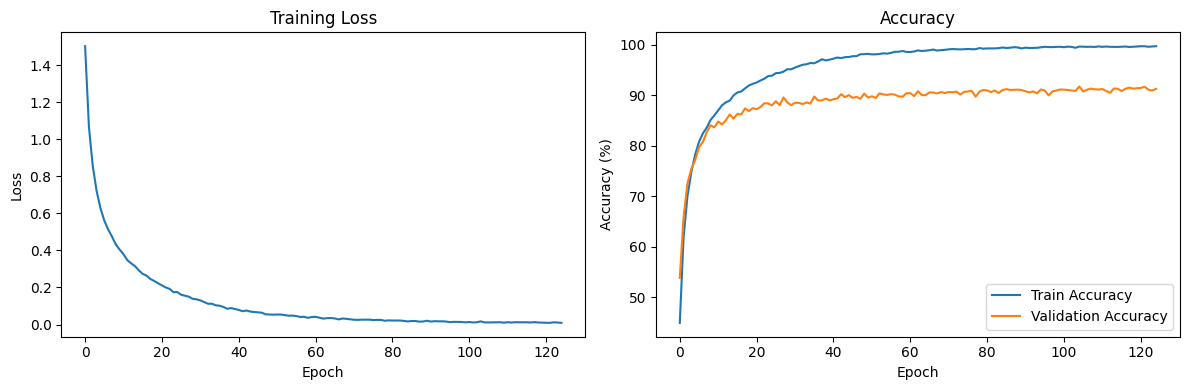

In [16]:
model_name = "ResNet"
state_dict = torch.load('/kaggle/working/ResNet_best_model.pth', weights_only=True)
model.load_state_dict(state_dict)
training_result['model']=model
accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

Training ViT...
Epoch 1/150, Train Loss: 1.9071, Train Acc: 28.53%, Val Acc: 33.31%, Time: 53.42s
Epoch 2/150, Train Loss: 1.7105, Train Acc: 36.45%, Val Acc: 39.80%, Time: 53.12s
Epoch 3/150, Train Loss: 1.5962, Train Acc: 41.24%, Val Acc: 44.18%, Time: 53.16s
Epoch 4/150, Train Loss: 1.5235, Train Acc: 44.00%, Val Acc: 44.93%, Time: 53.56s
Epoch 5/150, Train Loss: 1.4593, Train Acc: 46.94%, Val Acc: 47.48%, Time: 53.71s
Epoch 6/150, Train Loss: 1.4227, Train Acc: 47.94%, Val Acc: 46.68%, Time: 53.84s
Epoch 7/150, Train Loss: 1.3899, Train Acc: 49.38%, Val Acc: 50.07%, Time: 53.35s
Epoch 8/150, Train Loss: 1.3545, Train Acc: 50.72%, Val Acc: 49.30%, Time: 53.46s
Epoch 9/150, Train Loss: 1.3356, Train Acc: 51.34%, Val Acc: 50.67%, Time: 53.13s
Epoch 10/150, Train Loss: 1.3085, Train Acc: 52.44%, Val Acc: 52.81%, Time: 53.31s
Epoch 11/150, Train Loss: 1.2921, Train Acc: 52.93%, Val Acc: 54.15%, Time: 53.21s
Epoch 12/150, Train Loss: 1.2741, Train Acc: 53.62%, Val Acc: 54.31%, Time: 53.1

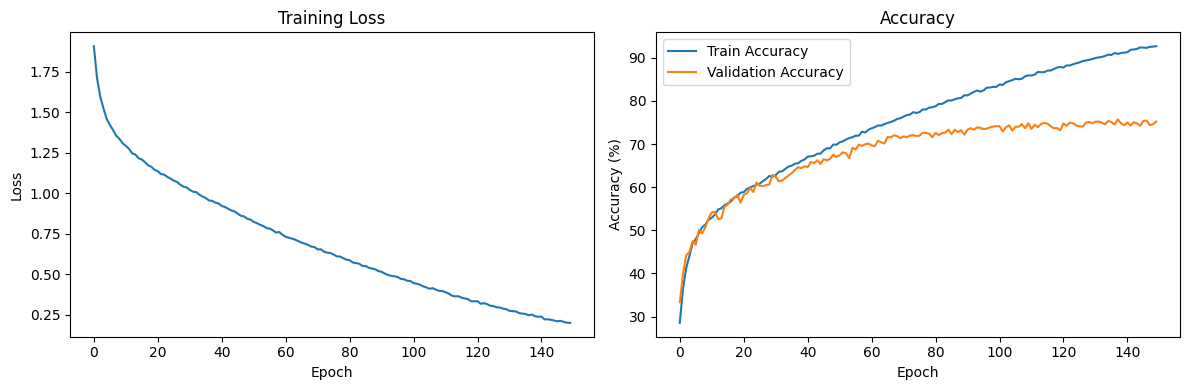

In [17]:
model_name = "ViT"
model = ViT() 

train_losses[model_name] = []
train_accuracies[model_name] = []
test_accuracies[model_name] = []
val_accuracies[model_name] = []

print(f"Training {model_name}...")
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

training_result = train_model(
    model, model_name, trainloader, valloader, testloader,
    criterion, optimizer, epochs=150, patience=20
)

train_losses[model_name] = training_result['train_losses']
train_accuracies[model_name] = training_result['train_accuracies']
val_accuracies[model_name] = training_result['val_accuracies']

accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


Per-class Accuracy:
plane: 77.10% (771/1000)
car: 88.00% (880/1000)
bird: 69.80% (698/1000)
cat: 51.70% (517/1000)
deer: 68.50% (685/1000)
dog: 69.80% (698/1000)
frog: 79.80% (798/1000)
horse: 83.10% (831/1000)
ship: 89.30% (893/1000)
truck: 76.80% (768/1000)

Final Results for ViT:
Best Validation Accuracy: 75.72%
Test Accuracy: 75.15%
Total Training Time: 8026.83s
Inference Time: 4.3892s per batch


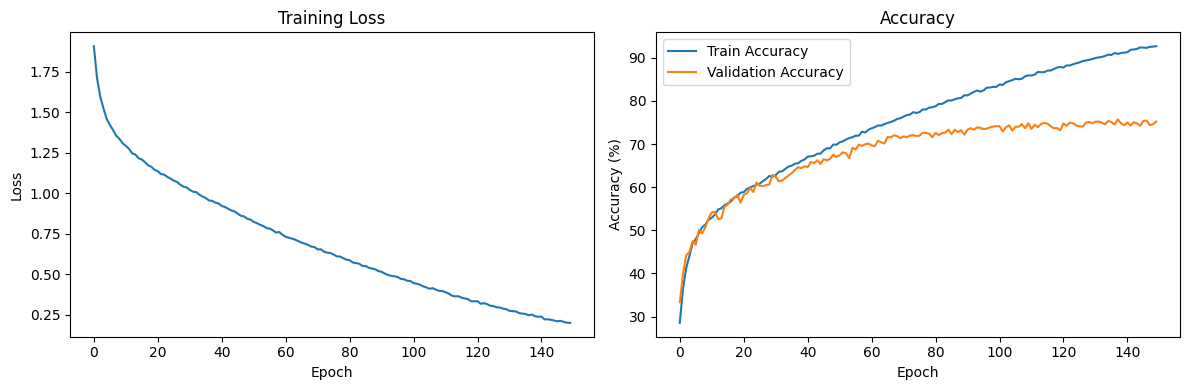

In [18]:
model_name = "ViT"
state_dict = torch.load('/kaggle/working/ViT_best_model.pth', weights_only=True)
model.load_state_dict(state_dict)
training_result['model']=model
accuracy, inference_time = evaluate_model(training_result['model'], testloader)

eval_results = evaluate_model_final(model, testloader, num_classes=10)
print("\nPer-class Accuracy:")
for class_idx, acc in eval_results['class_accuracies'].items():
    print(f"{classes[class_idx]}: {acc:.2f}% ({eval_results['class_correct'][class_idx]}/{eval_results['class_total'][class_idx]})")

results[model_name] = {
    "Accuracy": eval_results['overall_accuracy'],
    "Training Time": training_result['training_time'],
    "Inference Time": eval_results['inference_time'],
    "Best Val Accuracy": training_result['best_accuracy'],
    "Test Accuracy": training_result['test_accuracy']
}

print(f"\nFinal Results for {model_name}:")
print(f"Best Validation Accuracy: {training_result['best_accuracy']:.2f}%")
print(f"Test Accuracy: {training_result['test_accuracy']:.2f}%")
print(f"Total Training Time: {training_result['training_time']:.2f}s")
print(f"Inference Time: {inference_time:.4f}s per batch")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses[model_name], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accuracies[model_name], label='Train Accuracy')
plt.plot(val_accuracies[model_name], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

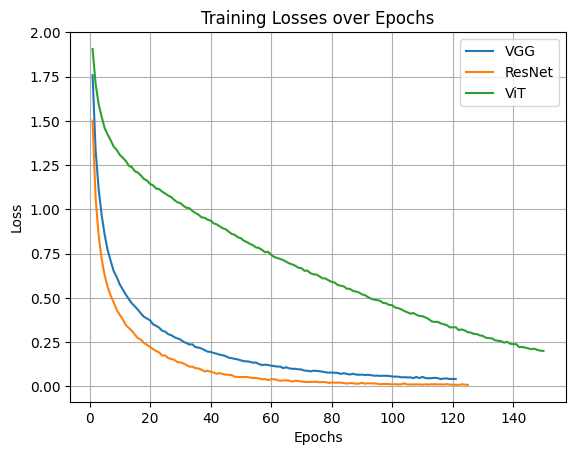

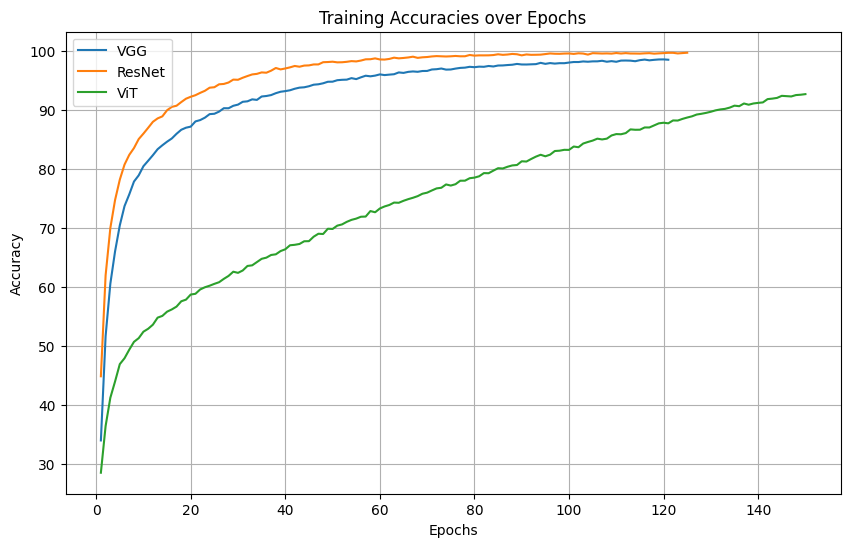

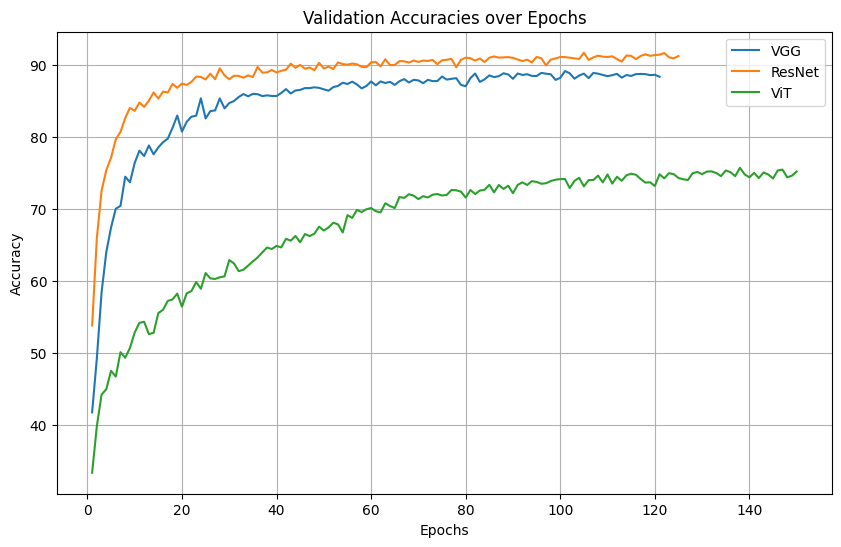

In [19]:
import matplotlib.pyplot as plt

train_loss = {
    "VGG": train_losses["VGG"],
    "ResNet": train_losses["ResNet"],
    "ViT": train_losses["ViT"]
}
train_accuracy = {
    "VGG": train_accuracies["VGG"],
    "ResNet": train_accuracies["ResNet"],
    "ViT": train_accuracies["ViT"]
}
val_accuracy = {
    "VGG": val_accuracies["VGG"],
    "ResNet": val_accuracies["ResNet"],
    "ViT": val_accuracies["ViT"]
}
for model_name, losses in train_loss.items():
    epochs = range(1, len(losses) + 1)
    plt.plot(epochs, losses, label=model_name)

plt.title('Training Losses over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for model_name, accuracies in train_accuracy.items():
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, label=model_name)

plt.title('Training Accuracies over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for model_name, accuracies in val_accuracy.items():
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, label=model_name)

plt.title('Validation Accuracies over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()